<a href="https://colab.research.google.com/github/Mukunzijames/Formative3/blob/main/part1_Bivariate_Normal_Distribution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Education in Africa - Bivariate Normal Distribution Notebook

## About the Dataset

- This dataset contains information about **education across African countries**, covering indicators like literacy rates, school enrollment, and other education-related metrics over time.

- Source of data - [Kaggle: Education in Africa](https://www.kaggle.com/datasets/lydia70/education-in-africa?select=Education+in+General.csv)



## The objective

The goal of this notebook is to explore the **relationship between two education indicators** using  **Bivariate Normal Distribution**.





## Why Does This Matter?

 This helps us understand patterns like:

> *"Do countries with higher literacy rates also tend to have higher school enrollment?"*


In [36]:
!pip install -q pandas numpy matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from mpl_toolkits.mplot3d import Axes3D

1. **Load and explore the data** – We take a first look at the dataset, check what columns are available, and clean up any missing values.

In [37]:
df = pd.read_csv('Education in General.csv')
df.head()

,ISO_Code,Country,Year,"School life expectancy, primary to tertiary, male (years)","School life expectancy, primary to tertiary, female (years)","Government expenditure on primary education, US$ (millions)","Government expenditure on secondary education, US$ (millions)","Government expenditure on tertiary education, US$ (millions)",Government expenditure on primary education as a percentage of GDP (%),Government expenditure on secondary education as a percentage of GDP (%),Government expenditure on tertiary education as a percentage of GDP (%),Unnamed: 11,Unnamed: 12
0,DZA,Algeria,2010,13.88,14.65,#N/B,#N/B,#N/B,#N/B,#N/B,#N/B,NaN,NaN
1,AGO,Angola,2010,10.42,8.1,#N/B,#N/B,#N/B,2.08,0.53,0.4,NaN,NaN
2,BWA,Botswana,2010,#N/B,#N/B,#N/B,#N/B,#N/B,#N/B,#N/B,#N/B,NaN,NaN
3,BFA,Burkina Faso,2010,7.05,5.97,213.65,63.74,66.71,2.11,0.63,0.66,NaN,NaN
4,CPV,Cabo Verde,2010,11.76,12.95,#N/B,#N/B,#N/B,#N/B,#N/B,#N/B,NaN,NaN


In [38]:
print("\ndataframe columns:")
print(df.columns)
print("\ndataframe info")
df.info()


dataframe columns:
Index(['ISO_Code', 'Country', 'Year',
       'School life expectancy, primary to tertiary, male (years)',
       'School life expectancy, primary to tertiary, female (years)',
       'Government expenditure on primary education, US$ (millions)',
       'Government expenditure on secondary education, US$ (millions)',
       'Government expenditure on tertiary education, US$ (millions)',
       'Government expenditure on primary education as a percentage of GDP (%)',
       'Government expenditure on secondary education as a percentage of GDP (%)',
       'Government expenditure on tertiary education as a percentage of GDP (%)',
       'Unnamed: 11', 'Unnamed: 12'],
      dtype='object')

dataframe info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Data columns (total 13 columns):
 #   Column                                                                    Non-Null Count  Dtype  
---  ------                                                  

In [39]:
# 2. Convert columns to numeric
cols_to_convert = df.columns.drop(['ISO_Code', 'Country'])
df[cols_to_convert] = df[cols_to_convert].apply(pd.to_numeric, errors='coerce')

# 3. Drop empty columns
df = df.dropna(axis=1, how='all')

print("Data shape:", df.shape)
print("\nData types:")
print(df.dtypes)
df.head()

Data shape: (756, 11)

Data types:
ISO_Code                                                                     object
Country                                                                      object
Year                                                                          int64
School life expectancy, primary to tertiary, male (years)                   float64
School life expectancy, primary to tertiary, female (years)                 float64
Government expenditure on primary education, US$ (millions)                 float64
Government expenditure on secondary education, US$ (millions)               float64
Government expenditure on tertiary education, US$ (millions)                float64
Government expenditure on primary education as a percentage of GDP (%)      float64
Government expenditure on secondary education as a percentage of GDP (%)    float64
Government expenditure on tertiary education as a percentage of GDP (%)     float64
dtype: object


,ISO_Code,Country,Year,"School life expectancy, primary to tertiary, male (years)","School life expectancy, primary to tertiary, female (years)","Government expenditure on primary education, US$ (millions)","Government expenditure on secondary education, US$ (millions)","Government expenditure on tertiary education, US$ (millions)",Government expenditure on primary education as a percentage of GDP (%),Government expenditure on secondary education as a percentage of GDP (%),Government expenditure on tertiary education as a percentage of GDP (%)
0,DZA,Algeria,2010,13.88,14.65,NaN,NaN,NaN,NaN,NaN,NaN
1,AGO,Angola,2010,10.42,8.10,NaN,NaN,NaN,2.08,0.53,0.40
2,BWA,Botswana,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BFA,Burkina Faso,2010,7.05,5.97,213.65,63.74,66.71,2.11,0.63,0.66
4,CPV,Cabo Verde,2010,11.76,12.95,NaN,NaN,NaN,NaN,NaN,NaN


2. **Find the strongest relationship** – We compute a **correlation matrix** to figure out which two variables are most strongly linked to each other. The closer the correlation is to 1 (or -1), the stronger the relationship.

In [40]:
# 4. Correlation matrix – find strongest pair
corr_matrix = df.corr(numeric_only=True)

corr_pairs = corr_matrix.abs().unstack()
corr_pairs = corr_pairs[corr_pairs < 1]
sorted_pairs = corr_pairs.sort_values(ascending=False)

strongest_pair  = sorted_pairs.index[0]
strongest_value = sorted_pairs.iloc[0]

col_x, col_y = strongest_pair
print(f"Strongest correlation: '{col_x}' vs '{col_y}'  |r| = {strongest_value:.4f}")

Strongest correlation: 'Government expenditure on primary education as a percentage of GDP (%)' vs 'Government expenditure on tertiary education as a percentage of GDP (%)'  |r| = 1.0000


The auto-detected strongest pair has ρ ≈ 1.0, which causes the bivariate
normal formula to break down (division by √(1-ρ²) = 0). We therefore
inspect all correlations across the dataset and handpick a pair that is
strongly correlated but not perfect

In [41]:
corr_matrix = df.corr(numeric_only=True)
print(corr_matrix)

                                                        Year  \
Year                                                1.000000   
School life expectancy, primary to tertiary, ma...  0.194465   
School life expectancy, primary to tertiary, fe...  0.266939   
Government expenditure on primary education, US...  0.191687   
Government expenditure on secondary education, ...  0.207299   
Government expenditure on tertiary education, U...  0.256297   
Government expenditure on primary education as ...  0.117839   
Government expenditure on secondary education a...  0.118348   
Government expenditure on tertiary education as...  0.119751   

                                                    School life expectancy, primary to tertiary, male (years)  \
Year                                                                                         0.194465           
School life expectancy, primary to tertiary, ma...                                           1.000000           
School life expectan

In [42]:
col_x = 'School life expectancy, primary to tertiary, male (years)'
col_y = 'School life expectancy, primary to tertiary, female (years)'

In [43]:
#  4. Data cleaning – keep only the two columns, drop NaNs
data = df[[col_x, col_y]].dropna()
x = data[col_x].values
y = data[col_y].values

print(f"\nUsable rows after dropna: {len(x)}")
print('\nColumn X')
print(x)
print('\nColumn y')
print(y)


Usable rows after dropna: 260

Column X
[13.88 10.42  7.05 11.76 10.61  7.94 11.12  8.56  8.36  7.32 10.82  8.
  8.   13.47 10.77 11.25  8.3   5.19 11.71 10.26  8.27 12.46  7.09  9.27
 13.66 14.09 12.63  7.5  12.03 11.85  8.55 10.02 11.13  8.45 13.22 11.15
  9.87 10.87  9.58  8.06  8.22 13.56 10.49 11.63  8.63  5.49 11.89  8.77
 11.92 12.65  6.83 13.77 12.08  7.73 12.2  12.41 10.85  7.45 10.61  9.72
 11.43  8.46 11.41  9.71 11.34  9.77  8.68 14.16 10.37 11.99  5.7  12.13
 10.66  8.99 14.2  12.98  7.13 10.98  7.9  12.73 10.91 11.86  9.87 11.64
 13.3  11.53  9.71 10.97  7.14  8.92 14.15 10.99  9.55  9.   14.25  7.3
  8.56 10.87 13.04  7.97 12.81 13.01 10.97  9.11 11.94  9.17 11.5   9.08
 11.13 10.27 10.88 11.42  9.86  7.8  14.57 10.93 11.5  11.55  9.13 15.52
 13.34  7.32 12.98  8.3  12.78 13.24 10.98  8.48  9.29  8.48 11.59  9.36
 10.69  9.96  7.47  9.   14.1  10.94  6.46 11.06 12.43 15.81 14.04  7.32
  7.82 13.09  8.5  12.84 13.11 10.82  9.73 11.68 11.44  9.74  9.79  7.61
  8.41 14.08 

3. **Calculate key statistics** – For our two chosen variables, we calculate:
   - The **mean** (average value)
   - The **standard deviation** (how spread out the values are)
   - The **covariance and ρ (rho)** – which tells us *how* and *how strongly* the two variables move together

In [44]:
# Means

mu1 = np.mean(x)
mu2 = np.mean(y)

print(mu1)
print(mu2)

10.861692307692307
10.51853846153846


In [45]:

# Standard deviation(stdx, stdy)

sigma1 = np.std(x)
sigma2 = np.std(y)
covariance = np.mean((x - mu1) * (y - mu2))
rho = covariance / (sigma1 * sigma2)

print(sigma1, sigma2)
print(rho)

# Interpretation
if   abs(rho) < 0.3:  strength = "Weak"
elif abs(rho) < 0.7:  strength = "Moderate"
else:                  strength = "Strong"
direction = "Positive" if rho > 0 else "Negative"
print(f"\n {strength} {direction} correlation")

2.3844803137924844 3.1183303253105623
0.9366284688946498

 Strong Positive correlation


4. **Build the PDF function** – We implement the **Bivariate Normal PDF formula**, which is a mathematical way of describing the probability distribution of two variables at the same time.

In [46]:
def bivariate_normal_pdf(x, y, mu1, mu2, sigma1, sigma2, rho):
    normalization = 1.0 / (2 * np.pi * sigma1 * sigma2 * np.sqrt(1 - rho**2))
    x_norm = (x - mu1) / sigma1
    y_norm = (y - mu2) / sigma2
    z = (x_norm**2 - 2*rho*x_norm*y_norm + y_norm**2) / (1 - rho**2)
    return normalization * np.exp(-0.5 * z)


pdf_values = bivariate_normal_pdf(x, y, mu1, mu2, sigma1, sigma2, rho)
print(f"Min PDF: {np.min(pdf_values)}")
print(f"Max PDF: {np.max(pdf_values)}")
print(f"Mean PDF: {np.mean(pdf_values)}")

Min PDF: 2.7001331880247294e-06
Max PDF: 0.061090340321481564
Mean PDF: 0.03190879693768784


5. **Visualization** – We create two plots:
   - A **contour plot** (like a top-down heatmap showing where data is most concentrated)
   - A **3D surface plot** (the classic "bell curve" but in two dimensions)

In [47]:
# Define grid range
x_min, x_max = x.min(), x.max()
y_min, y_max = y.min(), y.max()

# Create 100x100 grid
x_grid = np.linspace(x_min - 0.2*(x_max-x_min),
                     x_max + 0.2*(x_max-x_min), 100)
y_grid = np.linspace(y_min - 0.2*(y_max-y_min),
                     y_max + 0.2*(y_max-y_min), 100)

X_grid, Y_grid = np.meshgrid(x_grid, y_grid)

# Calculate PDF for entire grid
Z_grid = bivariate_normal_pdf(X_grid, Y_grid, mu1, mu2, sigma1, sigma2, rho)

print(Z_grid)

[[1.26306215e-004 1.71182946e-004 2.20248775e-004 ... 5.80126621e-097
  5.07025713e-099 4.20682461e-101]
 [1.16764464e-004 1.66105270e-004 2.24322772e-004 ... 5.88833405e-095
  5.40177605e-097 4.70433176e-099]
 [1.02531708e-004 1.53097414e-004 2.17017498e-004 ... 5.67706170e-093
  5.46644137e-095 4.99692701e-097]
 ...
 [6.08753721e-112 9.05859990e-110 1.27966932e-107 ... 2.41632976e-006
  2.31871338e-006 2.11229788e-006]
 [3.83262110e-114 5.98621459e-112 8.87617604e-110 ... 1.67029867e-006
  1.68237167e-006 1.60867009e-006]
 [2.29198448e-116 3.75755211e-114 5.84811068e-112 ... 1.09671453e-006
  1.15946689e-006 1.16369814e-006]]


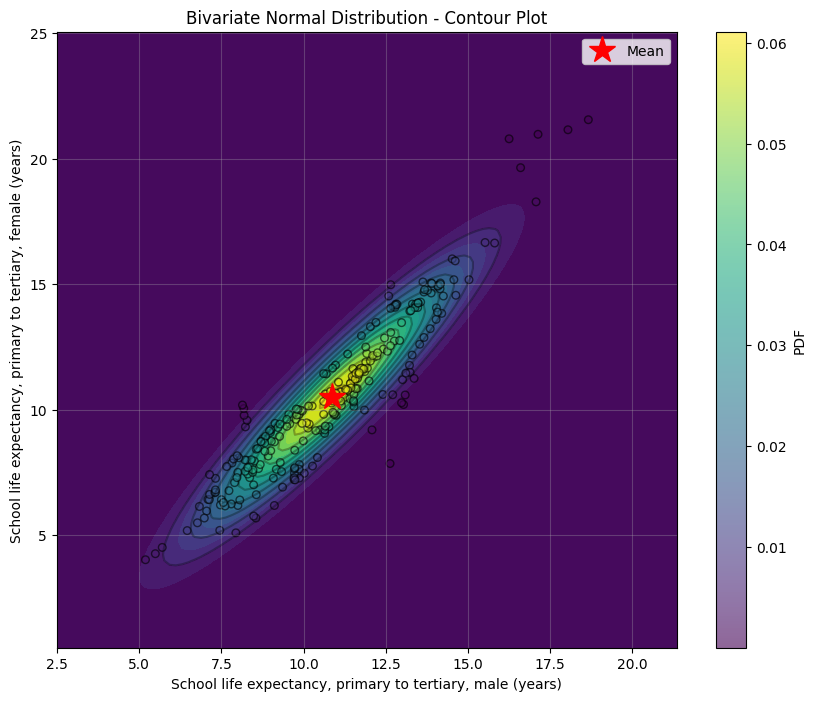

In [48]:

plt.figure(figsize=(10, 8))

# Filled contours (colored regions)
plt.contourf(X_grid, Y_grid, Z_grid, levels=20, cmap='viridis')

# Line contours (outlines)
plt.contour(X_grid, Y_grid, Z_grid, levels=10, colors='black', alpha=0.3)

# Plot actual data points
plt.scatter(x, y, c=pdf_values, s=30, cmap='viridis',
            edgecolors='black', alpha=0.6)

# Mark the mean
plt.plot(mu1, mu2, 'r*', markersize=20, label='Mean')

plt.colorbar(label='PDF')
plt.xlabel(col_x)
plt.ylabel(col_y)
plt.title('Bivariate Normal Distribution - Contour Plot')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Contour Plot - What Are We Looking At?

The contour plot gives us a top-down view of the bivariate normal distribution.
Think of it like a heatmap - the bright yellow/green center is where most of the
data points are concentrated, and the colors fade to purple as we move away from
the center.

A few things to notice:
- The shape is an **elongated ellipse**, not a circle. This is because ρ = 0.9366,
  meaning the two variables are strongly correlated. The more tilted and stretched
  the ellipse, the stronger the correlation.
- The **red star marks the mean** - the average school life expectancy for both
  males (~11.5 years) and females (~10.5 years). Most data points cluster around it.
- The points scattered outside the ellipse are **outliers** - countries that don't
  follow the general pattern, likely higher-income African nations with better
  education systems.

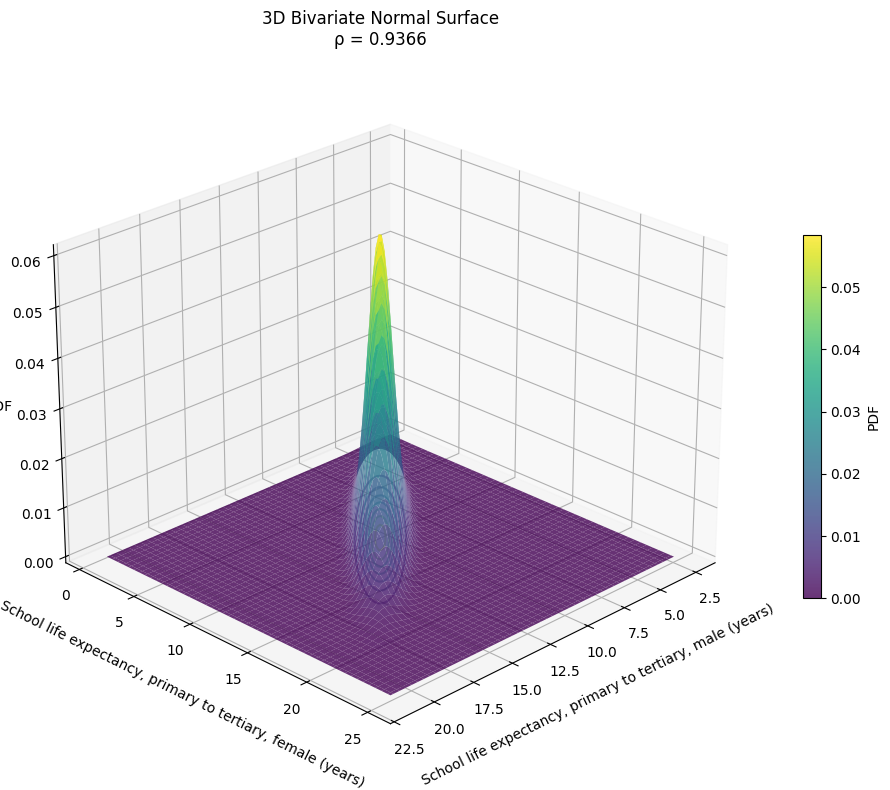

In [49]:
#  9. 3-D surface plot
fig = plt.figure(figsize=(12, 8))
ax  = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X_grid, Y_grid, Z_grid, cmap='viridis', alpha=0.8)
ax.contour(X_grid, Y_grid, Z_grid, zdir='z', offset=0, cmap='viridis', alpha=0.5)

ax.set_xlabel(col_x, labelpad=10)
ax.set_ylabel(col_y, labelpad=10)
ax.set_zlabel('PDF')
ax.set_title(f'3D Bivariate Normal Surface\nρ = {rho:.4f}')
ax.view_init(elev=25, azim=45)

plt.colorbar(surf, shrink=0.5, label='PDF')
plt.tight_layout()
plt.show()

## 3D Surface Plot - The Bell Curve in Two Dimensions

The 3D plot is essentially the same information as the contour plot, but viewed
from the side. The peak in the middle is the most "probable" region - where the
combination of male and female school life expectancy is most common across
African countries.

A few things to notice:
- The peak is **tall and narrow** because ρ is close to 1. When two variables move
  very closely together, the distribution gets squeezed into a tight ridge rather
  than a wide smooth hill.
- The base is nearly flat (close to 0) everywhere except near the center, meaning
  extreme combinations (e.g. very high male but very low female expectancy) are
  very rare.
- This shape is the 2D version of the classic **bell curve** you see in
  single-variable statistics.